# Pretrained ResNet-18
with speaker independent split.

Actors -> Train: 72, Val: 9, Test: 10
Epoch 1/10 | Train Acc: 46.47% | Val Acc: 45.66%
Epoch 2/10 | Train Acc: 61.09% | Val Acc: 48.10%
Epoch 3/10 | Train Acc: 74.33% | Val Acc: 44.72%
Epoch 4/10 | Train Acc: 84.38% | Val Acc: 50.00%
Epoch 5/10 | Train Acc: 91.04% | Val Acc: 53.52%
Epoch 6/10 | Train Acc: 92.28% | Val Acc: 50.14%
Epoch 7/10 | Train Acc: 96.86% | Val Acc: 52.17%
Epoch 8/10 | Train Acc: 95.26% | Val Acc: 49.86%
Epoch 9/10 | Train Acc: 95.37% | Val Acc: 51.49%
Epoch 10/10 | Train Acc: 93.72% | Val Acc: 51.63%


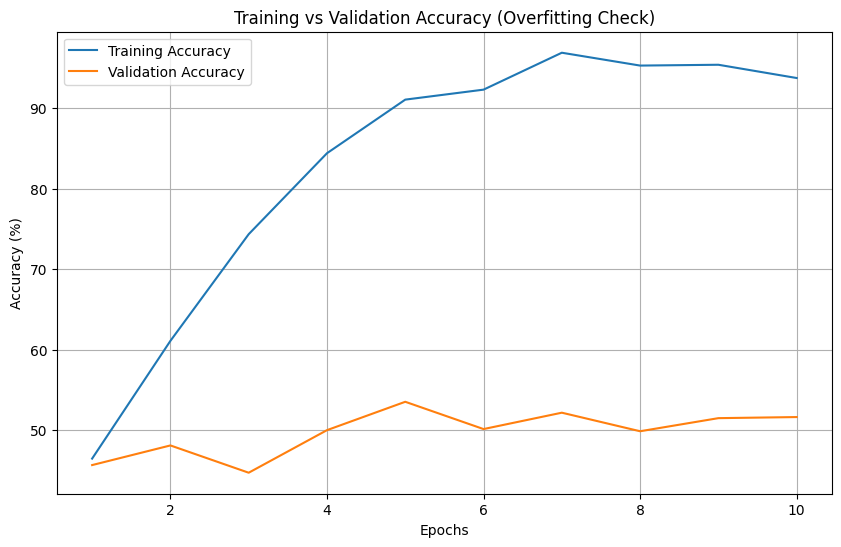


Final Test Accuracy (Unseen Actors): 54.05%


In [2]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Hyperparameters
BATCH_SIZE = 32
EPOCHS = 10
LEARNING_RATE = 0.0001
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Emotion mapping
EMOTIONS = {'ANG': 0, 'DIS': 1, 'FEA': 2, 'HAP': 3, 'NEU': 4, 'SAD': 5}

class CremaDataset(Dataset):
    def __init__(self, file_paths):
        self.file_paths = file_paths
        
    def __len__(self):
        return len(self.file_paths)
        
    def __getitem__(self, idx):
        file_path = self.file_paths[idx]
        spec = np.load(file_path)
        spec = np.nan_to_num(spec, nan=0.0, posinf=0.0, neginf=0.0)
        spec = np.expand_dims(spec, axis=0) 
        spec_tensor = torch.tensor(spec, dtype=torch.float32)
        
        filename = os.path.basename(file_path)
        emotion_code = filename.split('_')[2]
        label = EMOTIONS[emotion_code]
        
        return spec_tensor, torch.tensor(label, dtype=torch.long)

# 1. DATA SPLITTING (Actor-Based)
spec_path = "./features/mel_spectrograms"
all_files = [os.path.join(spec_path, f) for f in os.listdir(spec_path) if f.endswith('.npy')]

unique_actors = list(set([os.path.basename(f).split('_')[0] for f in all_files]))
unique_actors.sort() # Ensure consistency

# First, split off the training set (80%)
train_actors, temp_actors = train_test_split(unique_actors, test_size=0.2, random_state=42)
# Split the remaining 20% into Val and Test (50/50 of the remainder = 10% each of total)
val_actors, test_actors = train_test_split(temp_actors, test_size=0.5, random_state=42)

print(f"Actors -> Train: {len(train_actors)}, Val: {len(val_actors)}, Test: {len(test_actors)}")

train_files = [f for f in all_files if os.path.basename(f).split('_')[0] in train_actors]
val_files = [f for f in all_files if os.path.basename(f).split('_')[0] in val_actors]
test_files = [f for f in all_files if os.path.basename(f).split('_')[0] in test_actors]

train_loader = DataLoader(CremaDataset(train_files), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(CremaDataset(val_files), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(CremaDataset(test_files), batch_size=BATCH_SIZE, shuffle=False)

# 2. MODEL SETUP
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model.conv1 = nn.Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, len(EMOTIONS))
model = model.to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Lists to store metrics for plotting
history = {
    'train_acc': [],
    'val_acc': []
}

# 3. TRAINING LOOP
for epoch in range(EPOCHS):
    # --- Training Phase ---
    model.train()
    train_correct = 0
    train_total = 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        _, predicted = outputs.max(1)
        train_total += labels.size(0)
        train_correct += predicted.eq(labels).sum().item()
        
    epoch_train_acc = 100. * train_correct / train_total
    
    # --- Validation Phase ---
    model.eval()
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()
            
    epoch_val_acc = 100. * val_correct / val_total
    
    # Save metrics
    history['train_acc'].append(epoch_train_acc)
    history['val_acc'].append(epoch_val_acc)
    
    print(f"Epoch {epoch+1}/{EPOCHS} | Train Acc: {epoch_train_acc:.2f}% | Val Acc: {epoch_val_acc:.2f}%")

# 4. PLOTTING
plt.figure(figsize=(10, 6))
plt.plot(range(1, EPOCHS + 1), history['train_acc'], label='Training Accuracy', marker='')
plt.plot(range(1, EPOCHS + 1), history['val_acc'], label='Validation Accuracy', marker='')
plt.title('Training vs Validation Accuracy (Overfitting Check)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)
plt.show()

# 5. FINAL TEST
model.eval()
test_correct = 0
test_total = 0
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        outputs = model(inputs)
        _, predicted = outputs.max(1)
        test_total += labels.size(0)
        test_correct += predicted.eq(labels).sum().item()

print(f"\nFinal Test Accuracy (Unseen Actors): {100. * test_correct / test_total:.2f}%")

# Pretrained ResNet-18 with regularization
Regularization:
- Data Augmentation (Gaussian nose). TODO: Try pitch etc...
- Frequency and time masking
- Dropout
- Label smoothing
- Weight decay

Actors -> Train: 72, Val: 9, Test: 10
Epoch 1/20 | Train Acc: 32.02% | Val Acc: 41.06%
Epoch 2/20 | Train Acc: 40.90% | Val Acc: 44.99%
Epoch 3/20 | Train Acc: 45.81% | Val Acc: 44.72%
Epoch 4/20 | Train Acc: 49.25% | Val Acc: 44.99%
Epoch 5/20 | Train Acc: 52.77% | Val Acc: 49.59%
Epoch 6/20 | Train Acc: 56.01% | Val Acc: 50.54%
Epoch 7/20 | Train Acc: 58.00% | Val Acc: 54.20%
Epoch 8/20 | Train Acc: 61.36% | Val Acc: 53.79%
Epoch 9/20 | Train Acc: 62.94% | Val Acc: 50.54%
Epoch 10/20 | Train Acc: 65.35% | Val Acc: 50.95%
Epoch 11/20 | Train Acc: 67.88% | Val Acc: 52.17%
Epoch 12/20 | Train Acc: 70.19% | Val Acc: 55.69%
Epoch 13/20 | Train Acc: 72.19% | Val Acc: 53.79%
Epoch 14/20 | Train Acc: 74.28% | Val Acc: 53.12%
Epoch 15/20 | Train Acc: 77.33% | Val Acc: 55.42%
Epoch 16/20 | Train Acc: 79.51% | Val Acc: 53.25%
Epoch 17/20 | Train Acc: 80.88% | Val Acc: 53.12%
Epoch 18/20 | Train Acc: 82.87% | Val Acc: 55.83%
Epoch 19/20 | Train Acc: 84.30% | Val Acc: 54.61%
Epoch 20/20 | Train A

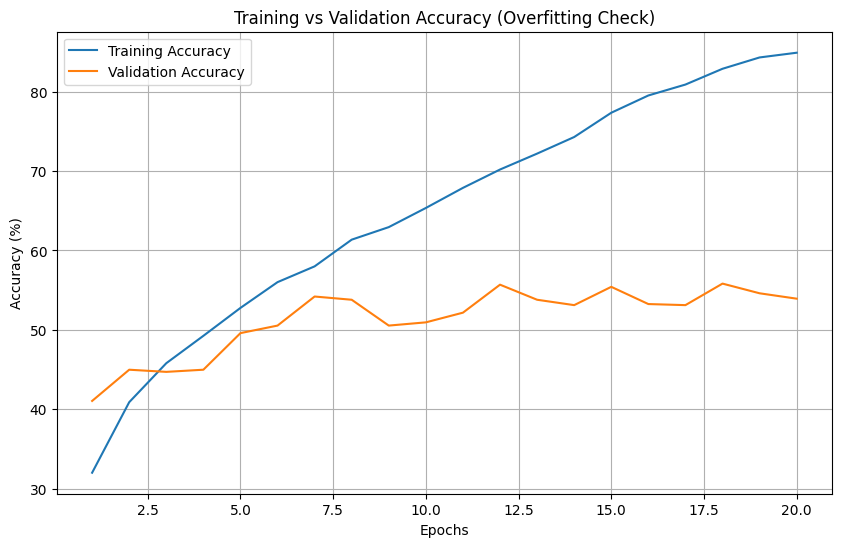


Final Test Accuracy (Unseen Actors): 61.55%


In [11]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# ==========================================
# 1. HYPERPARAMETERS & REGULARIZATION TUNING
# ==========================================
BATCH_SIZE = 32
EPOCHS = 20 # You might need slightly more epochs now that training is harder
LEARNING_RATE = 0.0001
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- Regularization Parameters ---
# Weight Decay (L2): Pulls weights towards zero to prevent extreme memorization.
# Try ranges: 1e-5 (light) to 1e-3 (heavy)
WEIGHT_DECAY = 1e-3 #1e-4      

# Label Smoothing: Prevents the model from being 100% certain about its predictions.
# Try ranges: 0.05 (light) to 0.2 (heavy)
LABEL_SMOOTHING = 0.1    

# Dropout: Percentage of neurons to randomly zero out in the final layer.
# Try ranges: 0.3 to 0.6
DROPOUT_RATE = 0.5        

# Data Augmentation: Standard deviation of Gaussian noise added to spectrograms.
# Try ranges: 0.001 (very subtle) to 0.01 (noticeable static)
ADD_NOISE_STD = 0.005    

# SpecAugment Masking: Max number of bins to randomly blackout.
# Try ranges: Freq (10-30), Time (20-50)
FREQ_MASK_PARAM = 10 #15      
TIME_MASK_PARAM = 20 #30      

EMOTIONS = {'ANG': 0, 'DIS': 1, 'FEA': 2, 'HAP': 3, 'NEU': 4, 'SAD': 5}

# ==========================================
# 2. DATASET WITH AUGMENTATION
# ==========================================
class CremaDataset(Dataset):
    def __init__(self, file_paths, is_train=False):
        self.file_paths = file_paths
        self.is_train = is_train # Only apply augmentation to the training set!
       
    def __len__(self):
        return len(self.file_paths)
       
    def __getitem__(self, idx):
        file_path = self.file_paths[idx]
        spec = np.load(file_path)
        spec = np.nan_to_num(spec, nan=0.0, posinf=0.0, neginf=0.0)
       
        # --- DATA AUGMENTATION (Frequency & Time Masking) ---
        if self.is_train:
            n_mels, n_steps = spec.shape
           
            # Frequency masking (horizontal blackout)
            if n_mels > FREQ_MASK_PARAM:
                f_mask = np.random.randint(0, FREQ_MASK_PARAM)
                f0 = np.random.randint(0, n_mels - f_mask)
                spec[f0:f0 + f_mask, :] = 0
               
            # Time masking (vertical blackout)
            if n_steps > TIME_MASK_PARAM:
                t_mask = np.random.randint(0, TIME_MASK_PARAM)
                t0 = np.random.randint(0, n_steps - t_mask)
                spec[:, t0:t0 + t_mask] = 0

        spec = np.expand_dims(spec, axis=0)
        spec_tensor = torch.tensor(spec, dtype=torch.float32)
       
        # --- DATA AUGMENTATION (Gaussian Noise) ---
        if self.is_train:
            noise = torch.randn_like(spec_tensor) * ADD_NOISE_STD
            spec_tensor = spec_tensor + noise
       
        filename = os.path.basename(file_path)
        emotion_code = filename.split('_')[2]
        label = EMOTIONS[emotion_code]
       
        return spec_tensor, torch.tensor(label, dtype=torch.long)

# ==========================================
# 3. DATA SPLITTING
# ==========================================
spec_path = "./features/mel_spectrograms"
all_files = [os.path.join(spec_path, f) for f in os.listdir(spec_path) if f.endswith('.npy')]

unique_actors = list(set([os.path.basename(f).split('_')[0] for f in all_files]))
unique_actors.sort()

train_actors, temp_actors = train_test_split(unique_actors, test_size=0.2, random_state=42)
val_actors, test_actors = train_test_split(temp_actors, test_size=0.5, random_state=42)

print(f"Actors -> Train: {len(train_actors)}, Val: {len(val_actors)}, Test: {len(test_actors)}")

train_files = [f for f in all_files if os.path.basename(f).split('_')[0] in train_actors]
val_files = [f for f in all_files if os.path.basename(f).split('_')[0] in val_actors]
test_files = [f for f in all_files if os.path.basename(f).split('_')[0] in test_actors]

# Notice we pass is_train=True ONLY to the train loader
train_loader = DataLoader(CremaDataset(train_files, is_train=True), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(CremaDataset(val_files, is_train=False), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(CremaDataset(test_files, is_train=False), batch_size=BATCH_SIZE, shuffle=False)

# ==========================================
# 4. MODEL SETUP WITH DROPOUT
# ==========================================
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model.conv1 = nn.Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)

# Add DROPOUT before the final classification layer
num_ftrs = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(p=DROPOUT_RATE),
    nn.Linear(num_ftrs, len(EMOTIONS))
)

model = model.to(DEVICE)

# Add LABEL SMOOTHING to the Loss function
criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)

# Add WEIGHT DECAY to the Optimizer
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

history = {'train_acc': [], 'val_acc': []}

# ==========================================
# 5. TRAINING LOOP
# ==========================================
for epoch in range(EPOCHS):
    model.train()
    train_correct = 0
    train_total = 0
   
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
       
        _, predicted = outputs.max(1)
        train_total += labels.size(0)
        train_correct += predicted.eq(labels).sum().item()
       
    epoch_train_acc = 100. * train_correct / train_total
   
    model.eval()
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()
           
    epoch_val_acc = 100. * val_correct / val_total
    history['train_acc'].append(epoch_train_acc)
    history['val_acc'].append(epoch_val_acc)
   
    print(f"Epoch {epoch+1}/{EPOCHS} | Train Acc: {epoch_train_acc:.2f}% | Val Acc: {epoch_val_acc:.2f}%")

# ==========================================
# 6. PLOTTING & EVALUATION
# ==========================================
plt.figure(figsize=(10, 6))
plt.plot(range(1, EPOCHS + 1), history['train_acc'], label='Training Accuracy', marker='')
plt.plot(range(1, EPOCHS + 1), history['val_acc'], label='Validation Accuracy', marker='')
plt.title('Training vs Validation Accuracy (Overfitting Check)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)
plt.show()

model.eval()
test_correct = 0
test_total = 0
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        outputs = model(inputs)
        _, predicted = outputs.max(1)
        test_total += labels.size(0)
        test_correct += predicted.eq(labels).sum().item()

print(f"\nFinal Test Accuracy (Unseen Actors): {100. * test_correct / test_total:.2f}%")

# Pretrained ResNet-18 with regularization and learning rate decay

Epoch 1/20 | Train: 31.65% | Val: 41.06% | LR: 0.000100
Epoch 2/20 | Train: 40.63% | Val: 45.53% | LR: 0.000100
Epoch 3/20 | Train: 43.84% | Val: 49.73% | LR: 0.000100
Epoch 4/20 | Train: 47.18% | Val: 47.02% | LR: 0.000100
Epoch 5/20 | Train: 51.15% | Val: 48.64% | LR: 0.000100
Epoch 6/20 | Train: 53.97% | Val: 50.54% | LR: 0.000100
Epoch 7/20 | Train: 56.96% | Val: 52.17% | LR: 0.000100
Epoch 8/20 | Train: 60.27% | Val: 50.95% | LR: 0.000100
Epoch 9/20 | Train: 61.19% | Val: 52.85% | LR: 0.000100
Epoch 10/20 | Train: 65.30% | Val: 50.81% | LR: 0.000100
Epoch 11/20 | Train: 68.46% | Val: 51.76% | LR: 0.000100
Epoch 12/20 | Train: 69.68% | Val: 53.39% | LR: 0.000100
Epoch 13/20 | Train: 73.02% | Val: 54.61% | LR: 0.000100
Epoch 14/20 | Train: 74.87% | Val: 53.39% | LR: 0.000100
Epoch 15/20 | Train: 77.71% | Val: 53.52% | LR: 0.000100
Epoch 16/20 | Train: 79.92% | Val: 53.66% | LR: 0.000050
Epoch 17/20 | Train: 84.04% | Val: 52.85% | LR: 0.000050
Epoch 18/20 | Train: 88.17% | Val: 53.25

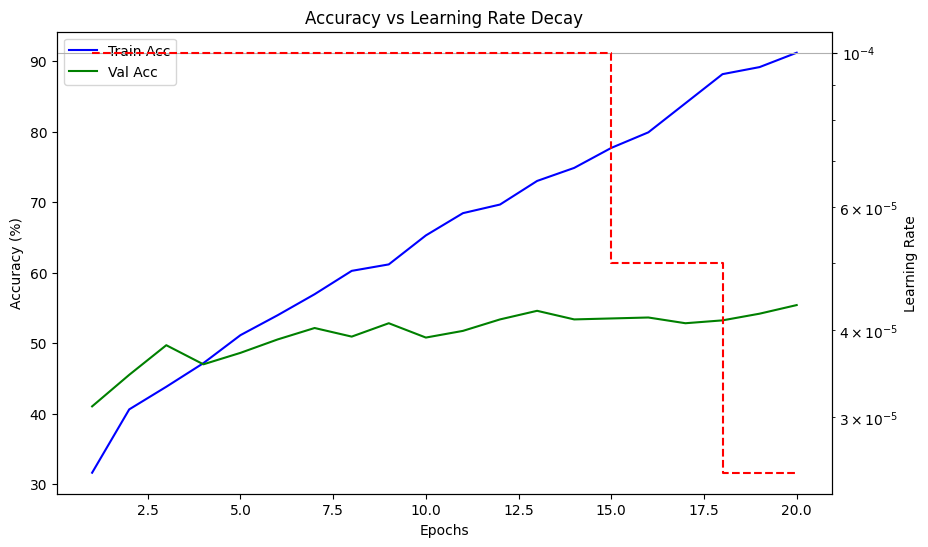


Final Test Accuracy (Unseen Actors): 60.32%


In [10]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# ==========================================
# 1. HYPERPARAMETERS & REGULARIZATION TUNING
# ==========================================
BATCH_SIZE = 32
EPOCHS = 20 
LEARNING_RATE = 0.0001
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- Regularization Parameters ---
WEIGHT_DECAY = 1e-3       # Increased to punish memorization more
LABEL_SMOOTHING = 0.1     
DROPOUT_RATE = 0.5        
ADD_NOISE_STD = 0.005     

# SpecAugment Masking (Slightly relaxed to help initial learning)
FREQ_MASK_PARAM = 10      
TIME_MASK_PARAM = 20      

# --- Scheduler Parameters ---
# Factor: multiply LR by this (0.5 = cut in half)
# Patience: wait this many epochs with no improvement before dropping
SCHEDULER_FACTOR = 0.5    
SCHEDULER_PATIENCE = 2    

EMOTIONS = {'ANG': 0, 'DIS': 1, 'FEA': 2, 'HAP': 3, 'NEU': 4, 'SAD': 5}

# ==========================================
# 2. DATASET WITH AUGMENTATION
# ==========================================
class CremaDataset(Dataset):
    def __init__(self, file_paths, is_train=False):
        self.file_paths = file_paths
        self.is_train = is_train 
        
    def __len__(self):
        return len(self.file_paths)
        
    def __getitem__(self, idx):
        file_path = self.file_paths[idx]
        spec = np.load(file_path)
        spec = np.nan_to_num(spec, nan=0.0, posinf=0.0, neginf=0.0)
        
        if self.is_train:
            n_mels, n_steps = spec.shape
            if n_mels > FREQ_MASK_PARAM:
                f_mask = np.random.randint(0, FREQ_MASK_PARAM)
                f0 = np.random.randint(0, n_mels - f_mask)
                spec[f0:f0 + f_mask, :] = 0
            if n_steps > TIME_MASK_PARAM:
                t_mask = np.random.randint(0, TIME_MASK_PARAM)
                t0 = np.random.randint(0, n_steps - t_mask)
                spec[:, t0:t0 + t_mask] = 0

        spec = np.expand_dims(spec, axis=0) 
        spec_tensor = torch.tensor(spec, dtype=torch.float32)
        
        if self.is_train:
            noise = torch.randn_like(spec_tensor) * ADD_NOISE_STD
            spec_tensor = spec_tensor + noise
        
        filename = os.path.basename(file_path)
        emotion_code = filename.split('_')[2]
        label = EMOTIONS[emotion_code]
        
        return spec_tensor, torch.tensor(label, dtype=torch.long)

# ==========================================
# 3. DATA SPLITTING 
# ==========================================
spec_path = "./features/mel_spectrograms"
all_files = [os.path.join(spec_path, f) for f in os.listdir(spec_path) if f.endswith('.npy')]

unique_actors = list(set([os.path.basename(f).split('_')[0] for f in all_files]))
unique_actors.sort() 

train_actors, temp_actors = train_test_split(unique_actors, test_size=0.2, random_state=42)
val_actors, test_actors = train_test_split(temp_actors, test_size=0.5, random_state=42)

train_files = [f for f in all_files if os.path.basename(f).split('_')[0] in train_actors]
val_files = [f for f in all_files if os.path.basename(f).split('_')[0] in val_actors]
test_files = [f for f in all_files if os.path.basename(f).split('_')[0] in test_actors]

train_loader = DataLoader(CremaDataset(train_files, is_train=True), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(CremaDataset(val_files, is_train=False), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(CremaDataset(test_files, is_train=False), batch_size=BATCH_SIZE, shuffle=False)

# ==========================================
# 4. MODEL SETUP
# ==========================================
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model.conv1 = nn.Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)

num_ftrs = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(p=DROPOUT_RATE),
    nn.Linear(num_ftrs, len(EMOTIONS))
)

model = model.to(DEVICE)
criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

# --- Scheduler Initialization ---
# mode='max' because we want to maximize Validation Accuracy
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', 
                                                 factor=SCHEDULER_FACTOR, 
                                                 patience=SCHEDULER_PATIENCE)

history = {'train_acc': [], 'val_acc': [], 'lr': []}

# ==========================================
# 5. TRAINING LOOP
# ==========================================
for epoch in range(EPOCHS):
    model.train()
    train_correct = 0
    train_total = 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        _, predicted = outputs.max(1)
        train_total += labels.size(0)
        train_correct += predicted.eq(labels).sum().item()
        
    epoch_train_acc = 100. * train_correct / train_total
    
    model.eval()
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()
            
    epoch_val_acc = 100. * val_correct / val_total
    
    # --- Step the Scheduler ---
    scheduler.step(epoch_val_acc)
    
    # Track current LR for curiosity
    current_lr = optimizer.param_groups[0]['lr']
    history['train_acc'].append(epoch_train_acc)
    history['val_acc'].append(epoch_val_acc)
    history['lr'].append(current_lr)
    
    print(f"Epoch {epoch+1}/{EPOCHS} | Train: {epoch_train_acc:.2f}% | Val: {epoch_val_acc:.2f}% | LR: {current_lr:.6f}")

# ==========================================
# 6. PLOTTING
# ==========================================
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot Accuracy
ax1.plot(range(1, EPOCHS + 1), history['train_acc'], label='Train Acc', color='blue')
ax1.plot(range(1, EPOCHS + 1), history['val_acc'], label='Val Acc', color='green')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy (%)')
ax1.legend(loc='upper left')

# Create a second y-axis to show the Learning Rate drop
ax2 = ax1.twinx()
ax2.step(range(1, EPOCHS + 1), history['lr'], label='LR', color='red', linestyle='--')
ax2.set_ylabel('Learning Rate')
ax2.set_yscale('log') # Log scale makes LR changes easier to see

plt.title('Accuracy vs Learning Rate Decay')
plt.grid(True)
plt.show()

# Final Evaluation
model.eval()
test_correct = 0
test_total = 0
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        outputs = model(inputs)
        _, predicted = outputs.max(1)
        test_total += labels.size(0)
        test_correct += predicted.eq(labels).sum().item()

print(f"\nFinal Test Accuracy (Unseen Actors): {100. * test_correct / test_total:.2f}%")